In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt #visualizations
import nltk #for basics
import re #regular expressions cleaning the data
from nltk.corpus import stopwords # to remove be verbs unwanted words
from nltk.tokenize import word_tokenize #splitting the words
from nltk.sentiment import SentimentIntensityAnalyzer
from collections import Counter
from wordcloud import WordCloud

#download required NLTK files
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('vader_lexicon')
nltk.download('punkt_tab')


data = {
    "Review": [
        "The product quality is excellent and delivery was very fast.",
        "Very bad packaging and the item was damaged.",
        "Customer service was helpful and responsive.",
        "The delivery was delayed and support team did not respond.",
        "Amazing product. Worth the money.",
        "Poor quality product and terrible experience.",
        "Fast shipping and good packaging.",
        "The product stopped working after two days.",
        "Excellent service and great quality.",
        "Late delivery and bad customer support."
    ]
}

# Create DataFrame
df = pd.DataFrame(data)

#display first few rows
print("Customer Reviews Dataset")
print(df.head())


Customer Reviews Dataset
                                              Review
0  The product quality is excellent and delivery ...
1       Very bad packaging and the item was damaged.
2       Customer service was helpful and responsive.
3  The delivery was delayed and support team did ...
4                  Amazing product. Worth the money.


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [10]:
import re
from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    words = text.split()
    words = [word for word in words if word not in stop_words]
    cleaned_text = " ".join(words)
    return cleaned_text
df['Cleaned_review'] = df['Review'].apply(clean_text)
print(df[['Review', 'Cleaned_review']])

                                              Review  \
0  The product quality is excellent and delivery ...   
1       Very bad packaging and the item was damaged.   
2       Customer service was helpful and responsive.   
3  The delivery was delayed and support team did ...   
4                  Amazing product. Worth the money.   
5      Poor quality product and terrible experience.   
6                  Fast shipping and good packaging.   
7        The product stopped working after two days.   
8               Excellent service and great quality.   
9            Late delivery and bad customer support.   

                             Cleaned_review  
0   product quality excellent delivery fast  
1                bad packaging item damaged  
2       customer service helpful responsive  
3     delivery delayed support team respond  
4               amazing product worth money  
5  poor quality product terrible experience  
6              fast shipping good packaging  
7          prod

In [14]:
sia = SentimentIntensityAnalyzer()
def analyze_sentiment(reviews):
  sentiment_scores = sia.polarity_scores(reviews)
  compound = sentiment_scores['compound'] # Fixed typo: score['compund'] to sentiment_scores['compound']
  if compound >= 0.05:
   return 'positive'
  elif compound <= -0.05:
   return 'negative'
  else:
   return 'neutral'
#apply sengtiment analysis
df['sentiment'] = df['Cleaned_review'].apply(analyze_sentiment)
print('\nSentiment Analysis')
print(df[['Review','sentiment']]) # Fixed typo: reviews to Review


Sentiment Analysis
                                              Review sentiment
0  The product quality is excellent and delivery ...  positive
1       Very bad packaging and the item was damaged.  negative
2       Customer service was helpful and responsive.  positive
3  The delivery was delayed and support team did ...  positive
4                  Amazing product. Worth the money.  positive
5      Poor quality product and terrible experience.  negative
6                  Fast shipping and good packaging.  positive
7        The product stopped working after two days.  negative
8               Excellent service and great quality.  positive
9            Late delivery and bad customer support.  negative


In [15]:
from collections import Counter
all_words = " ".join(df['Cleaned_review'])
word_list = all_words.split()
word_freq = Counter(word_list)
print("\nTop 10 Keywords")
print(word_freq.most_common(10))


Top 10 Keywords
[('product', 4), ('quality', 3), ('delivery', 3), ('excellent', 2), ('fast', 2), ('bad', 2), ('packaging', 2), ('customer', 2), ('service', 2), ('support', 2)]


In [16]:
negative_reviews = df[df['sentiment']== 'Negative']
negative_words = " ".join(negative_reviews['Cleaned_review'])
negative_word_list = negative_words.split()
complaint_freq = Counter(negative_word_list)
print("\n Top 10 common negative keywords")
print(complaint_freq.most_common(10))


 Top 10 common negative keywords
[]


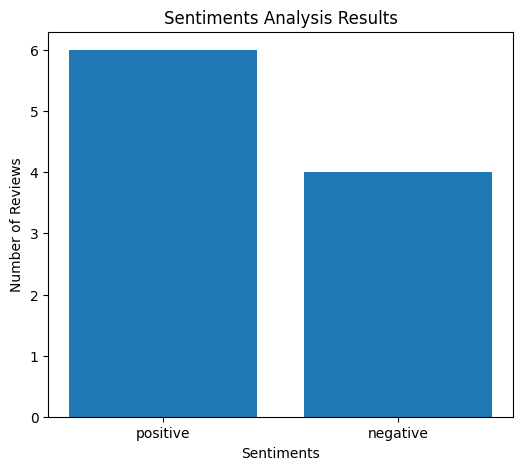

In [17]:
sentiment_counts = df['sentiment'].value_counts() #it will give category count
plt.figure(figsize = (6,5))
plt.bar(sentiment_counts.index,sentiment_counts.values)
plt.xlabel('Sentiments')
plt.ylabel('Number of Reviews')
plt.title('Sentiments Analysis Results')
plt.show()

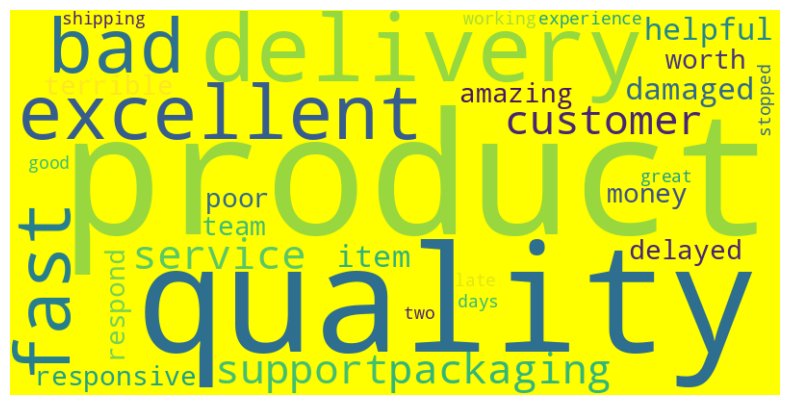

In [18]:
wordcloud = WordCloud(
width = 800,
height = 400,
background_color = 'yellow'
).generate(all_words)
plt.figure(figsize = (10,5))
plt.imshow(wordcloud,interpolation = 'bilinear')
plt.axis('off')
plt.show()